# Question 2 Clustering: Full Trait Model
This notebook evaluates the custom CSC 466 random forest using `data/processed/breed_clustering_full.csv`.

This notebook clusters dog breeds using the full set of numeric AKC trait scores.

In [1]:
from pathlib import Path
import sys

import pandas as pd

for base_dir in [Path.cwd(), *Path.cwd().parents]:
    if (base_dir / "data").exists() and (base_dir / "models").exists():
        PROJECT_ROOT = base_dir
        break
else:
    raise FileNotFoundError("Could not find project root with data/ and models/ folders.")

sys.path.insert(0, str(PROJECT_ROOT))

from models.clustering.kmeans import kmeans_main
from models.clustering.clustering_analysis_utils import (
    akc_group_traits_table,
    cluster_summary_with_akc,
    plot_cluster_composition,
    predictions_output,
)
from models.clustering.evaluation import print_cluster_report

In [2]:
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "breed_clustering_full.csv"
PREDICTION_OUTPUT_PATH = PROJECT_ROOT / "results" / "question2" / "clustering_full_predictions.csv"

## Cluster Summary on AKC Groups

In [3]:
data, labels, centroids, ground_truth = kmeans_main(DATA_PATH, 7, 0.000000001, 17)

PREDICTION_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
prediction_results = predictions_output(DATA_PATH, labels, PREDICTION_OUTPUT_PATH, centroids)

print_cluster_report(data, labels, ground_truth)
cluster_summary = cluster_summary_with_akc(prediction_results, data, labels, DATA_PATH, centroids)
cluster_summary


Overall Metrics
Overall silhouette score: 0.1
Rand Index: 0.76
Average radius / average intercluster distance: 1.33


Trait Cluster,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6,Cluster 7
Metric,,,,,,,
Cluster Size,19,46,24,48,23,22,20
Most Common AKC Group,Working Group,Sporting Group,Working Group,Terrier Group,Herding Group,Terrier Group,Terrier Group
Most Common AKC Group Count,5,16,11,14,10,7,5
Predicted AKC Group,Working Group,Sporting Group,Working Group,Terrier Group,Herding Group,Terrier Group,Terrier Group
Distance To Predicted AKC Group,2.14,1.35,1.14,0.96,1.8,2.14,1.88
AKC Rand Index,0.67,0.64,0.72,0.62,0.71,0.69,0.67
Silhouette Score,0.1,0.08,0.06,0.11,0.15,0.12,0.05
Radius,3.47,3.7,4.34,4.51,3.81,3.78,4.25


### Cluster Centroids vs AKC Group Traits Averages

In [4]:
cluster_traits = pd.DataFrame(
    centroids.round(2).T,
    index=data.columns,
    columns=[f"Cluster {i}" for i in range(1, centroids.shape[0] + 1)]
)
cluster_traits.index.name = "Trait"
cluster_traits

,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6,Cluster 7
Trait,,,,,,,
Affectionate With Family,4.11,4.78,4.96,4.73,3.00,4.86,4.55
Good With Young Children,3.00,4.61,4.12,3.31,3.17,4.91,3.70
Good With Other Dogs,3.26,4.67,3.25,3.04,3.17,3.59,3.15
Shedding Level,2.63,2.85,3.12,2.48,2.83,2.59,1.30
Coat Grooming Frequency,2.05,1.98,1.71,1.92,2.26,3.23,3.60
Drooling Level,2.42,1.74,2.92,1.40,1.26,1.36,1.80
Openness To Strangers,2.84,4.00,3.38,3.46,2.74,4.41,2.95
Playfulness Level,3.05,4.02,3.67,3.56,3.09,4.32,3.50
Watchdog/Protective Nature,3.95,3.00,4.42,3.77,3.70,3.91,4.00


In [5]:
group_traits = akc_group_traits_table(DATA_PATH)
group_traits

AKC Group,Herding Group,Hound Group,Non-Sporting Group,Sporting Group,Terrier Group,Toy Group,Working Group
Trait,,,,,,,
Affectionate With Family,4.18,4.25,4.85,4.64,4.68,4.76,4.44
Good With Young Children,3.70,3.78,4.00,4.12,3.97,3.57,3.91
Good With Other Dogs,3.36,4.22,3.40,3.91,2.94,3.76,3.22
Shedding Level,2.82,2.50,2.50,2.70,2.16,2.33,2.97
Coat Grooming Frequency,2.42,1.66,2.50,2.33,2.35,2.57,2.22
Drooling Level,1.55,1.75,1.65,2.12,1.29,1.10,2.66
Openness To Strangers,3.12,3.22,3.80,3.73,3.65,3.81,3.31
Playfulness Level,3.64,3.38,3.80,3.85,3.68,3.81,3.53
Watchdog/Protective Nature,3.91,3.06,3.80,3.18,3.94,3.62,4.53


### How well do trait-based clusters line up with AKC Groups?

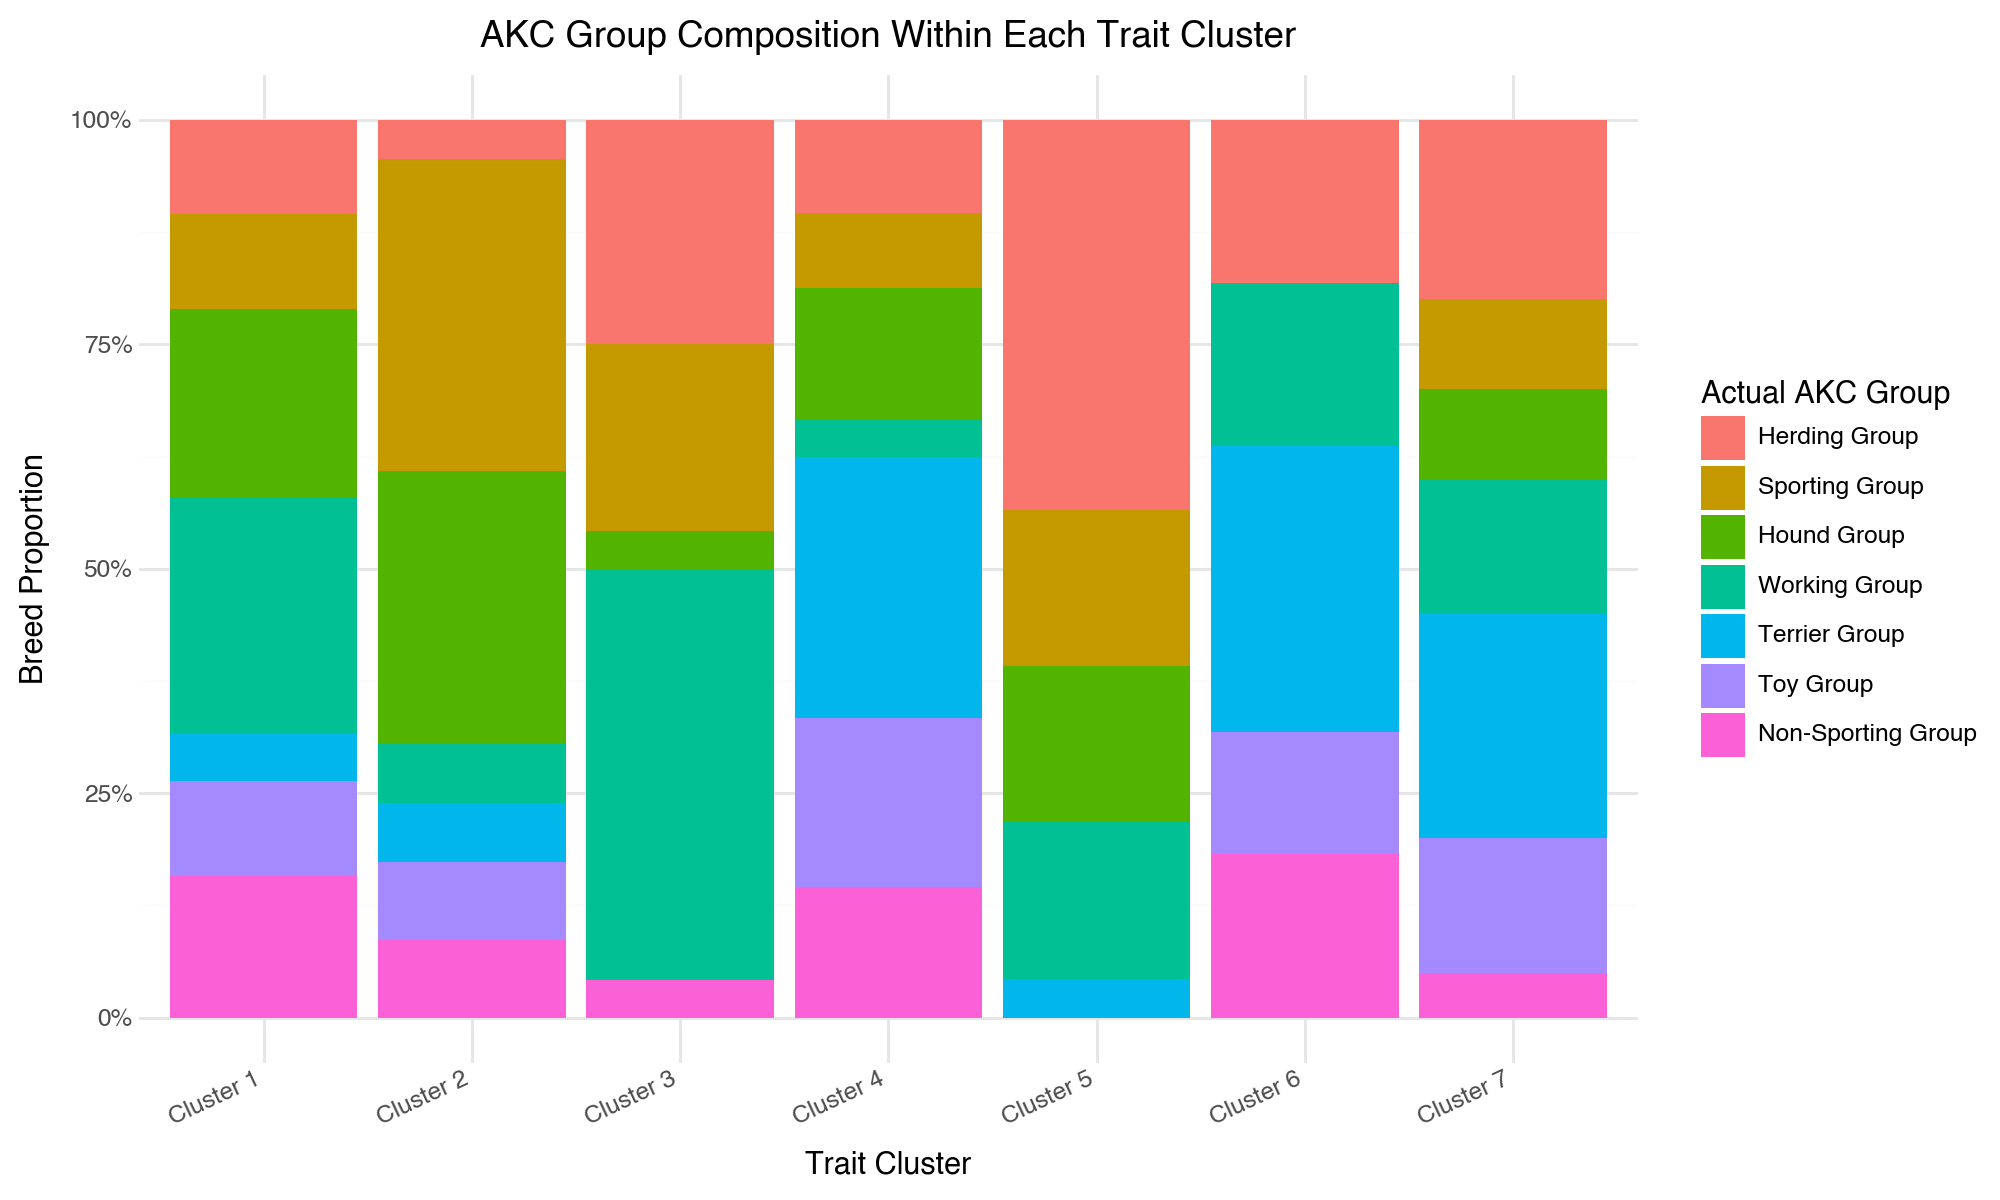

In [6]:
plot_cluster_composition(prediction_results)

## Prediction Output

This table saves each breed's assigned cluster with its average rank, popularity tier, and AKC group.

In [7]:
prediction_results.to_csv(PREDICTION_OUTPUT_PATH, index=False)
prediction_results

,Breed,Trait Cluster,Predicted AKC Group,Actual AKC Group,Distance To Predicted AKC Group,Correct AKC Prediction
0,Affenpinscher,Cluster 4,Terrier Group,Toy Group,0.96,False
1,Afghan Hound,Cluster 7,Terrier Group,Hound Group,1.88,False
2,Airedale Terrier,Cluster 7,Terrier Group,Terrier Group,1.88,True
3,Akita,Cluster 5,Herding Group,Working Group,1.80,False
4,Alaskan Malamute,Cluster 5,Herding Group,Working Group,1.80,False
...,...,...,...,...,...,...
197,Wire Fox Terrier,Cluster 6,Terrier Group,Terrier Group,2.14,True
198,Wirehaired Pointing Griffon,Cluster 3,Working Group,Sporting Group,1.14,False
199,Wirehaired Vizsla,Cluster 2,Sporting Group,Sporting Group,1.35,True
200,Xoloitzcuintli,Cluster 4,Terrier Group,Non-Sporting Group,0.96,False
